<a href="https://colab.research.google.com/github/budennovsk/Pandas/blob/master/%D0%9D%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%BA%D0%BE_%D0%B2%D1%81%D0%B5%D0%BC%D1%83_%D1%83%D1%80%D0%BE%D0%BA%D1%83_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install optuna implicit faiss-cpu gensim catboost rectools

In [2]:
import optuna
import random

import polars as pl
import pandas as pd
import numpy as np

from typing import List, Any
import scipy.sparse as sp
from tqdm import tqdm

import implicit
import faiss
from gensim.models import Word2Vec

from catboost import Pool, CatBoost, CatBoostClassifier, CatBoostRanker
from sklearn.model_selection import train_test_split

In [3]:
# раскоментируйте код ниже, чтобы скачать данные
!wget -q   https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -q ml-1m.zip

replace ml-1m/movies.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ml-1m/ratings.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace ml-1m/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [185]:
ratings = pd.read_csv(
    "ml-1m/ratings.dat",
    delimiter="::",
    header=None,
    names=["user_id", "item_id", "rating", "timestamp"],
    engine="python",
)
ratings = pl.from_pandas(ratings).filter(pl.col("rating") >= 4)
ratings

user_id,item_id,rating,timestamp
i64,i64,i64,i64
1,1193,5,978300760
1,3408,4,978300275
1,2355,5,978824291
1,1287,5,978302039
1,2804,5,978300719
…,…,…,…
6040,1089,4,956704996
6040,1094,5,956704887
6040,562,5,956704746


In [275]:
trt = ratings.to_pandas()

grouped_df = trt.groupby("user_id").agg({
    "item_id": lambda x: list(x),
    "rating": lambda x: list(x),
}).reset_index()

# Разделяем на train/test
grouped_df["train_item_ids"] = grouped_df["item_id"].apply(lambda x: x[:-5])
grouped_df["test_item_ids"] = grouped_df["item_id"].apply(lambda x: x[-5:])
grouped_df["train_ratings"] = grouped_df["rating"].apply(lambda x: x[:-5])
grouped_df["test_ratings"] = grouped_df["rating"].apply(lambda x: x[-5:])

# Оставляем только нужные колонки
grouped_df = grouped_df[["user_id", "train_item_ids", "train_ratings", "test_item_ids", "test_ratings"]]

grouped_df["user_id"] = range(len(grouped_df))

grouped_df = pl.from_pandas(grouped_df)
grouped_df


user_id,train_item_ids,train_ratings,test_item_ids,test_ratings
i64,list[i64],list[i64],list[i64],list[i64]
0,"[1193, 3408, … 1207]","[5, 4, … 4]","[2028, 531, … 1246]","[5, 4, … 4]"
1,"[1357, 3068, … 2943]","[5, 4, … 4]","[318, 1207, … 1247]","[5, 4, … 5]"
2,"[3421, 1394, … 2006]","[4, 4, … 4]","[2871, 2115, … 2081]","[4, 4, … 4]"
3,"[3468, 2951, … 2366]","[5, 4, … 4]","[1387, 1201, … 1240]","[5, 5, … 5]"
4,"[2987, 2333, … 2692]","[4, 4, … 4]","[32, 1897, … 714]","[4, 4, … 4]"
…,…,…,…,…
6033,"[589, 3006, … 1093]","[5, 4, … 4]","[1094, 562, … 1099]","[4, 4, … 4]"
6034,"[3006, 2064, … 1077]","[4, 4, … 4]","[2028, 1080, … 1097]","[4, 4, … 5]"
6035,"[1419, 3088, … 3548]","[4, 5, … 4]","[356, 1210, … 1079]","[4, 4, … 5]"


In [276]:
median_seq_len = (
    grouped_df
    .select(pl.col("train_item_ids").list.len().median().alias("median_len"))
    .item()
)

median_seq_len = int(median_seq_len)
print(f"средняя длина сессии {median_seq_len}")

средняя длина сессии 53


In [277]:
# соберем строчки для разреженной матрицы
rows = []
cols = []
values = []

for user_id, train_item_ids, train_ratings in grouped_df.select(
    "user_id", "train_item_ids", "train_ratings"
).rows():
    rows.extend([user_id] * len(train_item_ids))
    cols.extend(train_item_ids)
    values.extend(train_ratings)

user_item_data = sp.csr_matrix((values, (rows, cols)), dtype=np.float32)
user_item_data

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 545102 stored elements and shape (6038, 3953)>

In [278]:
TOP_K = 20
def apk(y_true, y_pred, k=TOP_K) -> float:
    """Average Precision@k for one user."""
    if not y_true:
        return 0.0
    y_true_set = set(y_true)
    score = 0.0
    hits = 0
    for i, p in enumerate(y_pred[:k], start=1):
        if p in y_true_set:
            hits += 1
            score += hits / i
    # нормируем на min(|y_true|, k) — стандартно для AP@k
    return score / min(len(y_true_set), k)

def ndcg_at_k(y_true, y_pred, k=TOP_K) -> float:
    """NDCG@k for one user (binary relevance)."""
    if not y_true:
        return 0.0
    y_true_set = set(y_true)
    dcg = 0.0
    for i, p in enumerate(y_pred[:k], start=1):
        if p in y_true_set:
            dcg += 1.0 / np.log2(i + 1)
    # ideal DCG: все релевантные в топе
    ideal_hits = min(len(y_true_set), k)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0

def hitrate_at_k(y_true, y_pred, k=TOP_K) -> int:
    """HitRate@k for one user."""
    if not y_true:
        return 0
    return int(len(set(y_true).intersection(y_pred[:k])) > 0)

In [279]:
RANDOM_STATE = 42

def set_seed():
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)


def get_recommendations(user_embs: np.array, item_embs: np.array, k: int = TOP_K):
    # строим индекс объектов
    index = faiss.IndexFlatIP(item_embs.shape[1])
    index.add(item_embs)

    # строим рекомендации с помощью dot-product расстояния
    # с запасом, чтобы после фильтрации просмотренных осталось хотя бы TOP_K
    return index.search(user_embs, k)

## ALS

В качестве первой модели возьмем ALS факторизацию и подберем оптимальные гиперпараметры с помощью библиотеки `optuna`

In [ ]:
# def objective(trial):
#     factors = trial.suggest_int("factors", 8, 128)
#     iterations = trial.suggest_int("iterations", 5, 30)
#     alpha = trial.suggest_float("alpha", 0.1, 5.0)
#     regularization = trial.suggest_float("regularization", 1e-3, 1.0)

#     print(
#         {
#             "factors": factors,
#             "iterations": iterations,
#             "alpha": alpha,
#             "regularization": regularization,
#         }
#     )

#     set_seed()
#     als_model = implicit.als.AlternatingLeastSquares(
#         factors=factors,
#         iterations=iterations,
#         random_state=RANDOM_STATE,
#         alpha=alpha,
#         regularization=regularization,
#     )
#     als_model.fit(user_item_data)

#     _, recs = get_recommendations(
#         als_model.user_factors, als_model.item_factors, TOP_K + median_seq_len
#     )

#     ndcg_list = []
#     for user_id, user_history, y_rel in grouped_df.select(
#         "user_id", "train_item_ids", "test_item_ids"
#     ).rows():
#         y_rec = [item_id for item_id in recs[user_id] if item_id not in user_history]
#         ndcg_list.append(user_ndcg(y_rel, y_rec))
#     mean_ndcg = np.mean(ndcg_list)
#     print(f"NDCG@{TOP_K} = {mean_ndcg}")
#     return mean_ndcg


# study = optuna.create_study(directions=("maximize",))
# study.optimize(objective, n_trials=1)

# study.best_params

In [280]:
set_seed()
als_model = implicit.als.AlternatingLeastSquares(
    # factors=70,
    # iterations=50,
    # random_state=RANDOM_STATE,
    # regularization=0.5,
    # alpha=0.7,
)
als_model.fit(user_item_data)

_, als_recs = get_recommendations(
    als_model.user_factors, als_model.item_factors, TOP_K
)

K =  TOP_K

# --- подготовим y_true (test) в порядке user_id ---
# предполагаем, что user_id = 0..n_users-1 и уникален
test_df = grouped_df.select(["user_id", "test_item_ids"]).sort("user_id")
y_true_list = test_df["test_item_ids"].to_list()   # list[list[int]]

# --- sanity checks ---
n_users = len(y_true_list)
if als_recs.shape[0] != n_users:
    raise ValueError(f"Размеры не совпадают: als_recs users={als_recs.shape[0]} vs grouped_df users={n_users}")

# --- считаем метрики ---
map_scores = np.empty(n_users, dtype=np.float64)
ndcg_scores = np.empty(n_users, dtype=np.float64)
hit_scores = np.empty(n_users, dtype=np.int32)

for u in range(n_users):
    y_true = y_true_list[u]
    y_pred = als_recs[u].tolist()  # list[int]
    map_scores[u] = apk(y_true, y_pred, k=K)
    ndcg_scores[u] = ndcg_at_k(y_true, y_pred, k=K)
    hit_scores[u] = hitrate_at_k(y_true, y_pred, k=K)

print(f"MAP@{K}     = {map_scores.mean():.4f}")
print(f"NDCG@{K}    = {ndcg_scores.mean():.4f}")
print(f"Hitrate@{K} = {hit_scores.mean():.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

MAP@20     = 0.0066
NDCG@20    = 0.0248
Hitrate@20 = 0.1900


## Word2Vec

В качестве второго подхода попробуем использовать сессионные рекомендации и модель w2v, для нее так же подберем оптимальные гиперпараметры с помощью библиотеки `optuna`

In [306]:
def map_at_k(y_true: List[int], y_pred: List[int], k: int = 20) -> float:
    """
    MAP@k (Mean Average Precision)
    y_true: [1566, 1907, 48] - релевантные товары
    y_pred: [356, 1073, 3052, ...] - предсказанные товары
    """
    y_true_set = set(y_true)
    y_pred_k = y_pred[:k]

    # if not y_true_set:
    #     return 0.0

    score = 0.0
    hits = 0
    for i, item in enumerate(y_pred_k, start=1):
        if item in y_true_set:
            hits += 1
            score += hits / i

    return score / min(len(y_true_set), k)


def ndcg_at_k(y_true: List[int], y_pred: List[int], k: int = 20) -> float:
    """
    NDCG@k (Normalized Discounted Cumulative Gain)
    y_true: [1566, 1907, 48] - релевантные товары
    y_pred: [356, 1073, 3052, ...] - предсказанные товары
    """
    y_true_set = set(y_true)
    y_pred_k = y_pred[:k]

    # if not y_true_set:
    #     return 0.0

    # DCG - реальный дисконтированный выигрыш
    dcg = 0.0
    for i, item in enumerate(y_pred_k, start=1):
        if item in y_true_set:
            dcg += 1.0 / np.log2(i + 1)

    # IDCG - идеальный дисконтированный выигрыш
    ideal_hits = min(len(y_true_set), k)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    return dcg / idcg if idcg > 0 else 0.0


def hitrate_at_k(y_true: List[int], y_pred: List[int], k: int = 20) -> int:
    """
    Hitrate@k (HR@k) - попал ли хотя бы один релевантный товар в топ-k?
    y_true: [1566, 1907, 48] - релевантные товары
    y_pred: [356, 1073, 3052, ...] - предсказанные товары
    Возвращает: 1 если попал, 0 если нет
    """
    y_true_set = set(y_true)
    y_pred_k = y_pred[:k]

    return int(len(y_true_set.intersection(y_pred_k)) > 0)

In [308]:
def evaluate_model(model):
    ndcg_list = []
    hitrate_list = []
    map_list = []

    for train_ids, y_rel in grouped_df.select("train_item_ids", "test_item_ids").rows():
        model_preds = model.predict_output_word(
            train_ids[-model.window :], topn=(TOP_K + len(train_ids))
        )
        # if model_preds is None:
        #     ndcg_list.append(0)
        #     hitrate_list.append(0)
        #     continue
        context = [x for x in train_ids[-model.window:] if x in model.wv]

        if not context:
            continue  # Пропускаем если нет контекста
        y_rec = [int(pred[0]) for pred in model_preds if int(pred[0]) not in train_ids]
        y_rel = [int(x) for x in y_rel]

        ndcg_list.append(ndcg_at_k(y_rel, y_rec, k=20))
        hitrate_list.append(hitrate_at_k(y_rel, y_rec, k=20))
        map_list.append(map_at_k(y_rel, y_rec, k=20))
    return np.mean(ndcg_list), np.mean(hitrate_list), np.mean(map_list)


def objective(trial):
    sg = trial.suggest_categorical("sg", [0, 1])
    window = trial.suggest_int("window", 1, 10)
    ns_exponent = trial.suggest_float("ns_exponent", -3, 3)
    negative = trial.suggest_int("negative", 3, 20)
    min_count = trial.suggest_int("min_count", 0, 20)
    vector_size = trial.suggest_categorical("vector_size", [16, 32, 64, 128])

    print(
        {
            "sg": sg,
            "window_len": window,
            "ns_exponent": ns_exponent,
            "negative": negative,
            "min_count": min_count,
            "vector_size": vector_size,
        }
    )

    set_seed()
    model = Word2Vec(
        grouped_df["train_item_ids"].to_list(),
        window=window,
        sg=sg,
        hs=0,
        min_count=min_count,
        vector_size=vector_size,
        negative=negative,
        ns_exponent=ns_exponent,
        seed=RANDOM_STATE,
        epochs=10,
    )

    mean_ndcg, mean_hitrate,map_mean = evaluate_model(model)
    print(f"NDCG@{TOP_K} = {mean_ndcg:.4f}, Hitrate@{TOP_K} = {mean_hitrate:.4f} map{TOP_K} = {map_mean:.4f}")
    return mean_ndcg


study = optuna.create_study(directions=("maximize",))
study.optimize(objective, n_trials=20)

study.best_params

[I 2026-03-19 15:44:27,684] A new study created in memory with name: no-name-acf66c03-29e7-498b-befa-34a50c55483c


{'sg': 1, 'window_len': 1, 'ns_exponent': 0.9384540584334111, 'negative': 12, 'min_count': 7, 'vector_size': 32}


[I 2026-03-19 15:44:56,494] Trial 0 finished with value: 0.13045932572531047 and parameters: {'sg': 1, 'window': 1, 'ns_exponent': 0.9384540584334111, 'negative': 12, 'min_count': 7, 'vector_size': 32}. Best is trial 0 with value: 0.13045932572531047.


NDCG@20 = 0.1305, Hitrate@20 = 0.5243 map20 = 0.0620
{'sg': 0, 'window_len': 3, 'ns_exponent': 2.136363545391318, 'negative': 17, 'min_count': 1, 'vector_size': 16}


[I 2026-03-19 15:45:19,312] Trial 1 finished with value: 0.09560123702366 and parameters: {'sg': 0, 'window': 3, 'ns_exponent': 2.136363545391318, 'negative': 17, 'min_count': 1, 'vector_size': 16}. Best is trial 0 with value: 0.13045932572531047.


...

[I 2026-03-19 15:56:13,874] Trial 18 finished with value: 0.1181315711762999 and parameters: {'sg': 0, 'window': 2, 'ns_exponent': 0.43601303129347546, 'negative': 7, 'min_count': 4, 'vector_size': 32}. Best is trial 0 with value: 0.13045932572531047.


NDCG@20 = 0.1181, Hitrate@20 = 0.4736 map20 = 0.0566
{'sg': 1, 'window_len': 4, 'ns_exponent': -2.4089075221464826, 'negative': 10, 'min_count': 8, 'vector_size': 64}


[I 2026-03-19 15:56:57,837] Trial 19 finished with value: 0.017848533276651642 and parameters: {'sg': 1, 'window': 4, 'ns_exponent': -2.4089075221464826, 'negative': 10, 'min_count': 8, 'vector_size': 64}. Best is trial 0 with value: 0.13045932572531047.


NDCG@20 = 0.0178, Hitrate@20 = 0.1402 map20 = 0.0056


{'sg': 1,
 'window': 1,
 'ns_exponent': 0.9384540584334111,
 'negative': 12,
 'min_count': 7,
 'vector_size': 32}

In [311]:

def evaluate_model(model):
    ndcg_list = []
    hitrate_list = []
    map_list = []
    y_rel_list = []
    y_rec_list = []

    for train_ids, y_rel in grouped_df.select("train_item_ids", "test_item_ids").iter_rows():
        # print(train_ids)
        # print(y_rel)
        # print(train_ids[-model.window :])
        context = [x for x in train_ids[-model.window:] if x in model.wv]

        if not context:
            continue  # Пропускаем если нет контекста

        model_preds = model.predict_output_word(
            train_ids[-model.window :], topn=(TOP_K + len(train_ids))
        )

        # if model_preds is None:
        #     ndcg_list.append(0)
        #     hitrate_list.append(0)
        #     map_list.append(0)
        #     y_rel_list.append(0)
        #     y_rec_list.append(0)
        #     continue

        y_rec = [int(pred[0]) for pred in model_preds if int(pred[0]) not in train_ids]
        y_rel = [int(x) for x in y_rel]
        # Подсчитываем метрики для k=20
        ndcg_list.append(ndcg_at_k(y_rel, y_rec, k=20))
        hitrate_list.append(hitrate_at_k(y_rel, y_rec, k=20))
        map_list.append(map_at_k(y_rel, y_rec, k=20))

        y_rel_list.append(y_rel)
        y_rec_list.append(y_rec)

         # Создаем датафрейм для визуального сравнения
    results_df = pl.DataFrame({
        'y_rel': y_rel_list,
        'y_rec': y_rec_list,
        'ndcg': ndcg_list,
        'hr': hitrate_list,
        'map': map_list
    })

    return results_df, np.mean(ndcg_list), np.mean(hitrate_list), np.mean(map_list)


set_seed()
w2v_model = Word2Vec(
    grouped_df['train_item_ids'].to_list(),
    hs=0,
    seed=RANDOM_STATE,
    epochs=30,
    sg=1,
    window=1,
    ns_exponent=0.9384540584334111,
    negative=12,
    min_count=7,
    vector_size=32,
)

results_df, mean_ndcg, mean_hitrate, mean_map = evaluate_model(w2v_model)

print(f'NDCG@20 = {mean_ndcg:.4f}, HR@20 = {mean_hitrate:.4f}, MAP@20 = {mean_map:.4f}')
print(results_df)

NDCG@20 = 0.1253, HR@20 = 0.5250, MAP@20 = 0.0587
shape: (6_012, 5)
┌──────────────────────┬──────────────────────┬──────────┬─────┬──────────┐
│ y_rel                ┆ y_rec                ┆ ndcg     ┆ hr  ┆ map      │
│ ---                  ┆ ---                  ┆ ---      ┆ --- ┆ ---      │
│ list[i64]            ┆ list[i64]            ┆ f64      ┆ i64 ┆ f64      │
╞══════════════════════╪══════════════════════╪══════════╪═════╪══════════╡
│ [2028, 531, … 1246]  ┆ [1206, 2947, … 36]   ┆ 0.0      ┆ 0   ┆ 0.0      │
│ [318, 1207, … 1247]  ┆ [1207, 1206, … 3747] ┆ 0.33916  ┆ 1   ┆ 0.2      │
│ [2871, 2115, … 2081] ┆ [1206, 2005, … 1136] ┆ 0.0      ┆ 0   ┆ 0.0      │
│ [1387, 1201, … 1240] ┆ [1704, 2355, … 3159] ┆ 0.0      ┆ 0   ┆ 0.0      │
│ [32, 1897, … 714]    ┆ [3499, 3481, … 1111] ┆ 0.0      ┆ 0   ┆ 0.0      │
│ …                    ┆ …                    ┆ …        ┆ …   ┆ …        │
│ [1094, 562, … 1099]  ┆ [1090, 1095, … 3507] ┆ 0.390327 ┆ 1   ┆ 0.215714 │
│ [2028, 1080, … 109

In [310]:
study.best_params

{'sg': 1,
 'window': 1,
 'ns_exponent': 0.9384540584334111,
 'negative': 12,
 'min_count': 7,
 'vector_size': 32}

In [293]:
print(w2v_model)

Word2Vec<vocab=3262, vector_size=64, alpha=0.025>


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


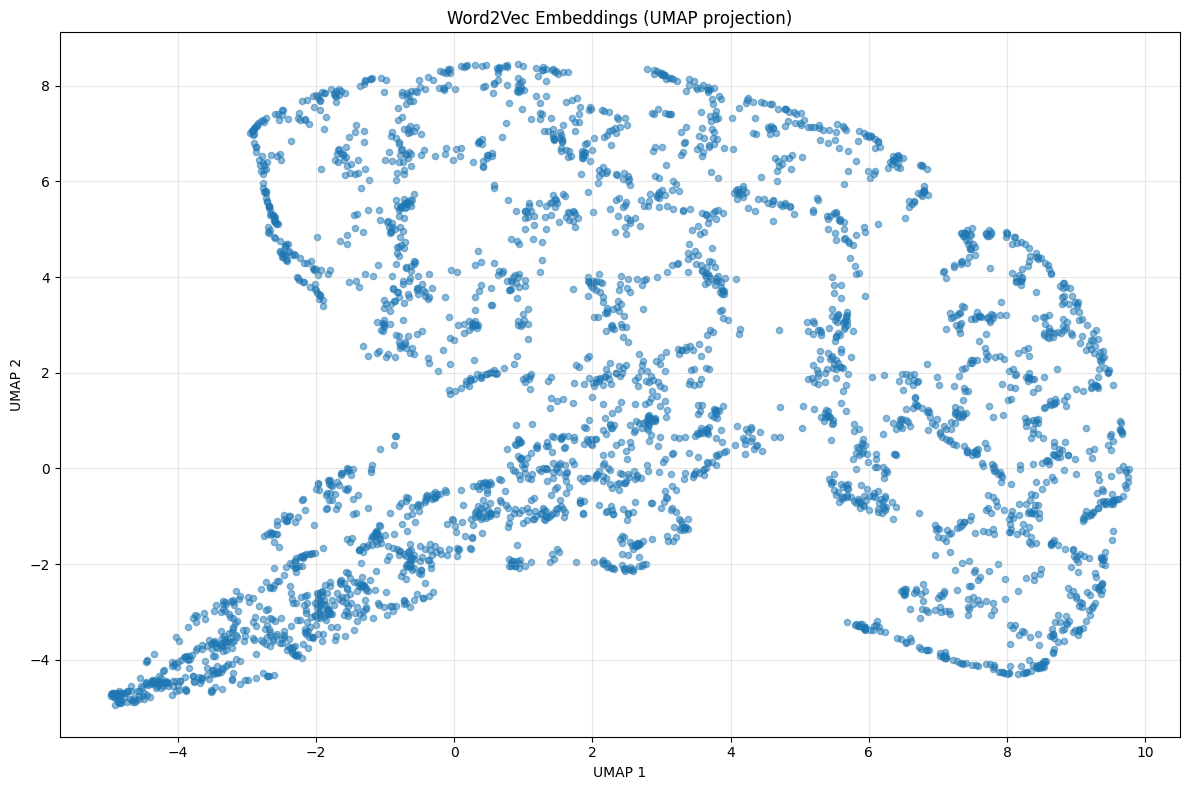

In [294]:
from umap import UMAP
import matplotlib.pyplot as plt

# 1. Получаем эмбеdinги из модели
embeddings = w2v_model.wv.vectors  # матрица (n_items, 16)
item_ids = w2v_model.wv.index_to_key  # названия товаров

# 2. Снижаем размерность до 2D с помощью UMAP
umap_model = UMAP(n_components=2, random_state=RANDOM_STATE)
embeddings_2d = umap_model.fit_transform(embeddings)

# 3. Строим график
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, s=20)

# Добавляем названия товаров (опционально, если не слишком много)
if len(item_ids) < 500:
    for i, item_id in enumerate(item_ids):
        plt.annotate(item_id, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=6)

plt.title('Word2Vec Embeddings (UMAP projection)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ранжирующая модель

Для ранжирования нам хотелось бы учитывать больше признаков для пользователей и объектов, в датасете movielens-1M, к счастью, все это имеется из коробки

Для _пользователей_ есть следующие признаки:
- gender (пол пользователя, категориальный признак)
- age (возраст пользователя, численный признак)
- occupation (род дейтельности, категориальный признак)
- zip_code (почтовый индекс пользователя, категориальный признак)

In [32]:
user_features = pd.read_csv(
    "ml-1m/users.dat",
    delimiter="::",
    header=None,
    names=["user_id", "gender", "age", "occupation", "zip_code"],
    engine="python",
)
user_features = pl.from_pandas(user_features)
user_features

user_id,gender,age,occupation,zip_code
i64,str,i64,i64,str
1,"""F""",1,10,"""48067"""
2,"""M""",56,16,"""70072"""
3,"""M""",25,15,"""55117"""
4,"""M""",45,7,"""02460"""
5,"""M""",25,20,"""55455"""
…,…,…,…,…
6036,"""F""",25,15,"""32603"""
6037,"""F""",45,1,"""76006"""
6038,"""F""",56,1,"""14706"""


Для _объектов_ есть следующие признаки:
- title (название тайтла, строка)
- genres (жанр тайтла, список категориальных признаков)

In [34]:
import polars as pl
import pandas as pd

item_features = pd.read_csv(
    "ml-1m/movies.dat",
    delimiter="::",
    header=None,
    names=["item_id", "title", "genres"],
    engine="python",
    encoding="latin-1",
)
item_features = pl.from_pandas(item_features)

item_features = item_features.with_columns(
    pl.col("genres").str.split("|").alias("genres")
)

item_features

item_id,title,genres
i64,str,list[str]
1,"""Toy Story (1995)""","[""Animation"", ""Children's"", ""Comedy""]"
2,"""Jumanji (1995)""","[""Adventure"", ""Children's"", ""Fantasy""]"
3,"""Grumpier Old Men (1995)""","[""Comedy"", ""Romance""]"
4,"""Waiting to Exhale (1995)""","[""Comedy"", ""Drama""]"
5,"""Father of the Bride Part II (1…","[""Comedy""]"
…,…,…
3948,"""Meet the Parents (2000)""","[""Comedy""]"
3949,"""Requiem for a Dream (2000)""","[""Drama""]"
3950,"""Tigerland (2000)""","[""Drama""]"


## Соберем датасет для ранжирования

В качестве **позитивных** объектов мы будем использовать те взаимодействия, где оценка >= 4

В качестве **негативных** объектов мы можем использовать те взаимодействия, где оценка < 4, однако для implicit реакции этот подход не всегда подходит и для простоты мы будем сэмплировать негативные примеры на примере сессионных рекомендаций

In [37]:
import numpy as np
import polars as pl

ns_exponent = 0.75
total = ratings.height

cnt_df = ratings.group_by("item_id").agg(pl.len().alias("cnt")).with_columns(
    (pl.col("cnt") / total).alias("p")
)

# items_set + вероятности
items_df = ratings.select("item_id").unique()
items_df = items_df.join(cnt_df.select(["item_id", "p"]), on="item_id", how="left").fill_null(0.0)

items_set = items_df["item_id"].to_numpy()
item_probs = items_df["p"].to_numpy().astype(np.float64) ** ns_exponent
item_probs = item_probs / item_probs.sum()

In [39]:
import numpy as np
import polars as pl

set_seed()

n_negatives = 3  # кол-во негативных примеров на один позитивный

ranking_dataset = []

# В Polars: group_by, и чтобы получить python-итерацию по строкам — iter_rows()
user_items = (
    ratings
    .group_by("user_id")
    .agg(pl.col("item_id").alias("item_ids"))   # item_ids будет list
)

for user_id, pos_ids in user_items.iter_rows():
    pos_ids = set(pos_ids)

    # хотим получить примерно len(pos_ids) * n_negatives негативов
    n_items_to_sample = min(len(item_probs), len(pos_ids) * (n_negatives + 1))

    sampled = np.random.choice(
        items_set,
        size=n_items_to_sample,
        replace=False,   # уникальные айтемы
        p=item_probs,    # сэмплирование с bias к популярным
    )

    neg_ids = [int(item_id) for item_id in sampled if int(item_id) not in pos_ids]

    # можно ограничить точное кол-во негативов:
    neg_ids = neg_ids[: len(pos_ids) * n_negatives]

    for item_id in pos_ids:
        ranking_dataset.append([user_id, int(item_id), 1])
    for item_id in neg_ids:
        ranking_dataset.append([user_id, int(item_id), 0])

ranking_dataset = pl.DataFrame(ranking_dataset, schema=["user_id", "item_id", "target"])
ranking_dataset

/tmp/ipykernel_6208/3547067651.py:40: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  ranking_dataset = pl.DataFrame(ranking_dataset, schema=["user_id", "item_id", "target"])


user_id,item_id,target
i64,i64,i64
1,1,1
1,260,1
1,2692,1
1,1028,1
1,1287,1
…,…,…
6040,3783,0
6040,292,0
6040,1225,0


In [41]:
# соединим датасет с признаками пользователей и объектов
ranking_dataset_with_features = (
    ranking_dataset.join(user_features, "user_id").join(item_features, "item_id")
).drop(
    ["title", "genres"]
)  # пока что мы не будем использовать признаки для объектов, вам предлагается попробовать
# вам предлагается попробовать эффективно закодировать эти признаки и еще улучшить метрики

ranking_dataset_with_features

user_id,item_id,target,gender,age,occupation,zip_code
i64,i64,i64,str,i64,i64,str
1,1,1,"""F""",1,10,"""48067"""
1,260,1,"""F""",1,10,"""48067"""
1,2692,1,"""F""",1,10,"""48067"""
1,1028,1,"""F""",1,10,"""48067"""
1,1287,1,"""F""",1,10,"""48067"""
…,…,…,…,…,…,…
6040,3783,0,"""M""",25,6,"""11106"""
6040,292,0,"""M""",25,6,"""11106"""
6040,1225,0,"""M""",25,6,"""11106"""


## Обучаем catboost

Большая часть признаков получилась категориальными, чтобы не думать над эффективным кодированием этих признаков мы воспользуемся библиотекой `catboost`

Класс Pool позволяет обернуть наши данные с возможностью указать группу для group-wise ранжирования

In [ ]:
train_dataset, test_dataset = train_test_split(
    ranking_dataset_with_features, test_size=0.1, random_state=RANDOM_STATE
)
# отсортируем, чтобы использовать group_id в классе Pool
train_dataset = train_dataset.sort("user_id")
test_dataset = test_dataset.sort("user_id")

cat_features = ["user_id", "item_id", "gender", "zip_code", "occupation"]

train_pool = Pool(
    train_dataset.drop(["target"]).to_pandas(),
    train_dataset["target"].to_list(),
    # используется для подсчета groupwise метрик, например NDCG
    group_id=train_dataset["user_id"].to_list(),
    cat_features=cat_features,
)

test_pool = Pool(
    test_dataset.drop(["target"]).to_pandas(),
    test_dataset["target"].to_list(),
    group_id=test_dataset["user_id"].to_list(),
    cat_features=cat_features,
)

# обучаем модель классификации, так как она работает сильно быстрее, чем модель ранжирования
# в качестве метрик можно смотреть на NDCG, MAP и AUC
ranking_model = CatBoostClassifier(
    **{
        "iterations": 300,
        "verbose": False,
        "random_state": RANDOM_STATE,
        "use_best_model": True,
        "custom_metric": [f"NDCG:top={TOP_K}", f"MAP:top={TOP_K}", "AUC"],
    }
)
ranking_model.fit(train_pool, plot=True, eval_set=test_pool)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

## Оценим результаты ранжирования

подготовим наши кандидаты в виде списков для каждого пользователя

In [ ]:
# сформируем датафрейм с кандидатами из модели als
als_candidates = pl.DataFrame(
    {
        "user_id": grouped_df["user_id"],
        "candidates": [
            [item_id for item_id in als_recs[user_id] if item_id not in user_history][
                :TOP_K
            ]
            for user_id, user_history in grouped_df.select(
                "user_id", "train_item_ids"
            ).rows()
        ],
    }
)
als_candidates

user_id,candidates
i64,list[i64]
1448,"[454, 1090, 2580]"
4840,"[3114, 2355, … 3100]"
72,"[1265, 1784, … 2268]"
4808,"[1240, 610, … 3396]"
4656,"[1393, 908, … 2916]"
448,"[2336, 3408, … 2987]"
1784,"[2916, 1196, … 541]"
4384,"[2706, 1394, … 1476]"
5840,"[597, 1035, … 3526]"


In [ ]:
def get_w2v_candidates(w2v_model, train_ids):
    model_preds = w2v_model.predict_output_word(
        train_ids[-w2v_model.window :], topn=(TOP_K + len(train_ids))
    )
    if model_preds is None:
        return []

    return [pred[0] for pred in model_preds if pred[0] not in train_ids][:TOP_K]


# сформируем датафрейм с кандидатами из модели w2v
w2v_candidates = pl.DataFrame(
    {
        "user_id": grouped_df["user_id"],
        "candidates": [
            get_w2v_candidates(w2v_model, train_ids)
            for train_ids in grouped_df["train_item_ids"].to_list()
        ],
    }
)
w2v_candidates

user_id,candidates
i64,list[i64]
1448,"[2985, 1242, … 3920]"
4840,"[529, 2797, … 377]"
72,"[3755, 3751, … 1208]"
4808,"[1089, 3911, … 556]"
4656,"[2018, 2019, … 1221]"
448,"[2762, 1028, … 1965]"
1784,"[1968, 353, … 355]"
4384,"[1090, 1097, … 705]"
5840,"[2018, 2019, … 540]"


In [ ]:
def predict_ranks(ranking_model, candidates_with_features):
    if isinstance(ranking_model, CatBoostRanker):
        return ranking_model.predict(candidates_with_features.to_pandas())
    else:
        return ranking_model.predict_proba(candidates_with_features.to_pandas())[:, 1]


candidates_with_features = (
    # объединяем все кандидаты в один список пар (user_id, item_id)
    pl.concat([als_candidates, w2v_candidates])
    .explode("candidates")
    .rename({"candidates": "item_id"})
    .unique()
    # добавляем признаки пользователей
    .join(user_features, "user_id")
    # добавляем признаки объектов
    .join(item_features, "item_id")
).drop(["title", "genres"])

candidates_with_features = candidates_with_features.with_columns(
    [
        # взвешиваем с помощью модели ранжирования кандидатов
        pl.Series(predict_ranks(ranking_model, candidates_with_features)).alias("rank")
    ]
)

candidates_with_features

user_id,item_id,gender,age,occupation,zip_code,rank
i64,i64,str,i64,i64,str,f64
1448,454,"""F""",25,3,"""17522""",0.387932
4840,589,"""F""",45,6,"""63135""",0.276843
4840,2571,"""F""",45,6,"""63135""",0.282576
4840,3255,"""F""",45,6,"""63135""",0.268616
72,1641,"""F""",45,0,"""55122""",0.278103
72,539,"""F""",45,0,"""55122""",0.294356
4656,1219,"""M""",25,17,"""94041""",0.341076
4656,866,"""M""",25,17,"""94041""",0.21189
448,2336,"""M""",25,17,"""80123""",0.190112


In [ ]:
grouped_candidates_with_features = candidates_with_features.groupby("user_id").agg(
    [pl.col("item_id"), pl.col("rank")]
)

reranked_candidates = []
for user_id, item_ids, item_ranks in grouped_candidates_with_features.rows():
    # для каждого пользователя сортируем оценки модели ранжирования и оставляем top-k объектов
    reranked_candidates.append(
        [user_id, [item_ids[ind] for ind in np.argsort(item_ranks)[::-1][:TOP_K]]]
    )

reranked_candidates = pl.DataFrame(
    reranked_candidates, schema=["user_id", "candidates_item_ids"]
)
reranked_candidates

user_id,candidates_item_ids
i64,list[i64]
3208,"[593, 2762, … 3671]"
3888,"[1196, 1198, … 1080]"
1152,"[2959, 2571, … 70]"
1592,"[1240, 2762, … 1095]"
2640,"[2762, 1580, … 1215]"
808,"[2858, 608, … 2020]"
1808,"[318, 3578, … 1012]"
336,"[3793, 1214, … 1690]"
5128,"[1196, 527, … 1220]"


оценим метрики для кандидатов по отдельности

In [ ]:
ndcg_list = []
hitrate_list = []

for y_rec, y_rel in (
    w2v_candidates.join(grouped_df, "user_id")
    .select("candidates", "test_item_ids")
    .rows()
):
    ndcg_list.append(user_ndcg(y_rel, y_rec))
    hitrate_list.append(user_hitrate(y_rel, y_rec))
print(
    f"NDCG@{TOP_K} = {np.mean(ndcg_list):.4f}, Hitrate@{TOP_K} = {np.mean(hitrate_list):.4f}"
)

NDCG@20 = 0.1570, Hitrate@20 = 0.5048


In [ ]:
ndcg_list = []
hitrate_list = []

for y_rec, y_rel in (
    als_candidates.join(grouped_df, "user_id")
    .select("candidates", "test_item_ids")
    .rows()
):
    ndcg_list.append(user_ndcg(y_rel, y_rec))
    hitrate_list.append(user_hitrate(y_rel, y_rec))
print(
    f"NDCG@{TOP_K} = {np.mean(ndcg_list):.4f}, Hitrate@{TOP_K} = {np.mean(hitrate_list):.4f}"
)

NDCG@20 = 0.0760, Hitrate@20 = 0.3264


и попробуем два подхода объединения кандидатов:
1. будем по очереди брать объекты на i-ой категории и соединять в один список
2. возьмем сначала n кандидатов из одного списка, затем из другого и так далее

In [ ]:
joined_candidates = (
    pl.concat([als_candidates, w2v_candidates])
    .groupby("user_id")
    .agg(pl.col("candidates"))
)

ndcg_list = []
hitrate_list = []

for candidates, y_rel in (
    joined_candidates.join(grouped_df, "user_id")
    .select("candidates", "test_item_ids")
    .rows()
):
    y_rec = [item_id for item_ids in list(zip(*candidates)) for item_id in item_ids]

    ndcg_list.append(user_ndcg(y_rel, y_rec))
    hitrate_list.append(user_hitrate(y_rel, y_rec))
print(
    f"NDCG@{TOP_K} = {np.mean(ndcg_list):.4f}, Hitrate@{TOP_K} = {np.mean(hitrate_list):.4f}"
)

NDCG@20 = 0.1351, Hitrate@20 = 0.5320


In [ ]:
joined_candidates = (
    pl.concat([als_candidates, w2v_candidates])
    .groupby("user_id")
    .agg(pl.col("candidates"))
)

ndcg_list = []
hitrate_list = []

for candidates, y_rel in (
    joined_candidates.join(grouped_df, "user_id")
    .select("candidates", "test_item_ids")
    .rows()
):
    y_rec = [
        item_id
        for item_ids in candidates
        for item_id in item_ids[: TOP_K // len(candidates)]
    ]

    ndcg_list.append(user_ndcg(y_rel, y_rec))
    hitrate_list.append(user_hitrate(y_rel, y_rec))
print(
    f"NDCG@{TOP_K} = {np.mean(ndcg_list):.4f}, Hitrate@{TOP_K} = {np.mean(hitrate_list):.4f}"
)

NDCG@20 = 0.1223, Hitrate@20 = 0.5421


ну и наконец оценим метрики для кандидатов после ранжирования

In [ ]:
ndcg_list = []
hitrate_list = []

for y_rec, y_rel in (
    reranked_candidates.join(grouped_df, "user_id")
    .select("candidates_item_ids", "test_item_ids")
    .rows()
):
    ndcg_list.append(user_ndcg(y_rel, y_rec))
    hitrate_list.append(user_hitrate(y_rel, y_rec))
print(
    f"NDCG@{TOP_K} = {np.mean(ndcg_list):.4f}, Hitrate@{TOP_K} = {np.mean(hitrate_list):.4f}"
)

NDCG@20 = 0.2405, Hitrate@20 = 0.6706


In [ ]:
print(f'NDCG@{TOP_K} +{(0.2496 / 0.1597 - 1)* 100:.2f}%')
print(f'Hitrate@{TOP_K} +{(0.6742 / 0.5099 - 1)* 100:.2f}%')

NDCG@20 +56.29%
Hitrate@20 +32.22%
